# 📘 Tutorial 4: Structured BO for Hierarchical Experimental Workflows

> This is the worked version of the notebook.
>
> All cells have been executed and include outputs, figures, and numerical results for reference.

In **Tutorial 3**, we extended BO in two directions where the meaning of the input variables became richer than ordinary design variables.

In the multi-fidelity setting, the optimiser had to decide not only **which design to evaluate**, but also **at what fidelity**. In the contextual setting, the optimiser had to decide **which design to choose under the current context**.

So the BO workflow was no longer just about choosing the next point in a design space. It became a workflow for making decisions under cost, approximation, and external conditions.

In this tutorial, we move to another important form of structure:

> **what changes when the experiment itself has an internal hierarchy, so that not all design variables play the same role?**

That is the focus of this notebook.

This is a different kind of extension from multi-fidelity or contextual BO. Here, all variables are still part of the experimental input, but they do not enter the workflow symmetrically.

Some variables determine **what material is made**. Other variables determine **how that material is operated or tested**.

This leads to a structured BO setting for **hierarchical experimental workflows**.

---

## Hierarchical experimental workflows

In many real optimisation problems, the experiment is naturally organised in stages.

A first stage may involve **synthesis or fabrication**. A second stage may involve **operation, testing, or characterisation**.

These two stages are connected, but they are not interchangeable.

In this tutorial, we represent that workflow using two groups of variables:

- **synthesis conditions** $U$,
- **operation conditions** $V$.

So the full experiment is written as:

$$
Z = [U,V].
$$

At first glance, this still looks like an ordinary BO problem over one concatenated input vector. But the scientific meaning is different.

The synthesis conditions determine the material that is produced. The operation conditions determine how that material is used or tested.

So the workflow has a natural hierarchy:

$$
U \longrightarrow \text{material properties} \longrightarrow V^*(U) \longrightarrow y(U,V).
$$

This means that the best operation condition can depend on the synthesis condition.

There may not be one globally best operating point independent of the material.

That is the key structural idea of the notebook.

---

## Flat BO versus structured BO

Once the workflow has this hierarchy, the usual BO question becomes more subtle.

A standard flat BO policy asks:

> **which full synthesis-operation pair should we evaluate next?**

That corresponds to treating every candidate as an ordinary vector:

$$
Z = [u_1,u_2,v_1,v_2].
$$

A structured BO policy asks a more workflow-aware question:

> **which synthesis condition is worth committing to, given the operation conditions that look promising under it?**

This difference matters because synthesis is often the more consequential decision.

If several operation conditions are available under one synthesis condition, the optimiser may want to reason about that synthesis condition as a group rather than only ranking isolated full pairs.

So this tutorial compares two viewpoints:

- **flat BO**, which selects directly in the full concatenated space;
- **two-stage structured BO**, which first scores synthesis conditions and then selects an operation condition under the chosen synthesis condition.

Random search is also included as a baseline.

---

## Why this topic matters

This tutorial is about a broader lesson in BO:

> realistic optimisation problems often have workflow structure that is not visible from the flat input vector alone.

If we ignore that structure, we may still run BO successfully. But we may miss opportunities to make the selection rule more aligned with how real experiments are actually organised.

In this notebook, the structure is relatively simple: synthesis first, operation second.

Even this simple hierarchy is enough to create different search behaviour.

It changes how we think about candidate quality, what it means to explore broadly, and how acquisition values should be aggregated before making the next decision.

So the goal is not only to optimise a synthetic objective. It is also to understand how BO changes when the experimental workflow itself has meaningful internal stages.

---

## What this notebook does

To make these ideas concrete, the notebook builds a synthetic objective with two linked stages.

The first part defines the synthesis and operation spaces, then constructs a hierarchical objective in which synthesis determines latent material properties and those material properties determine preferred operation conditions.

The second part builds a finite synthesis-operation candidate library and evaluates the full hidden objective over that library.

This gives a complete ground-truth benchmark that can be visualised and analysed.

The third part compares three sequential search policies:

- **flat BO**,
- **two-stage structured BO**,
- **random search**.

This lets us study not only which policy finds the best candidate, but also how each policy explores the synthesis space over time.

---

**This tutorial is designed to shift perspective**
- from *“all input variables are just coordinates in one optimisation space”*
- to *“some variables may define earlier-stage workflow decisions, while others define later-stage operating choices.”*

---

**The emphasis is on developing intuition for**
- why synthesis and operation variables may need to be treated differently,
- why a hierarchical objective can still be written in a flat BO-compatible form,
- why a structured selection rule can differ from flat BO even when the model and acquisition function are the same,
- and why exploring more distinct synthesis designs is not automatically better if that exploration is poorly targeted.

---

**Key ideas explored include**
- defining a synthetic hierarchical objective $y(U,V)$,
- visualising the synthesis-level and operation-level landscapes,
- comparing flat BO, structured BO, and random search on the same library,
- and analysing both performance discovery and synthesis-space exploration.

---

This tutorial serves as the bridge from:

- **multi-fidelity and contextual BO** in Tutorial 3,
- to **workflow-aware BO settings where internal experimental structure matters**.

---

**Recommended prerequisites**
- Completion of **Tutorials 1–3 of Part 6**
- Familiarity with Gaussian Process surrogates and acquisition functions in BoTorch
- Familiarity with the standard sequential BO loop

---

**Author**: Angze Li

**Last updated**: 2026-04-28

**Version**: v1.0

## 🔧 Setup

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from botorch.models import SingleTaskGP
from botorch.models.transforms import Normalize, Standardize
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import LogExpectedImprovement
from gpytorch.mlls import ExactMarginalLogLikelihood

warnings.filterwarnings("ignore")
torch.set_default_dtype(torch.double)


def set_seed(seed=0):
    torch.manual_seed(seed)
    np.random.seed(seed)


def style_ax(ax):
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)
    ax.tick_params(axis="both", labelsize=14)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight("bold")

## 1. Define the synthesis and operation spaces

This cell sets up the **hierarchical design space** for the structured BO part of the notebook.

The scientific picture is the following.

We imagine that we are optimising an electrochemical material workflow with two connected stages:

1. **synthesis**, where we decide how the material is made;
2. **operation**, where we decide how the material is tested.

The synthesis conditions are collected into a vector $U$, and the operation conditions are collected into a vector $V$.

For this tutorial, both stages have two controllable variables:

- **synthesis conditions**: precursor ratio and annealing temperature;
- **operation conditions**: electrolyte pH and applied potential.

All variables are scaled to the interval $[0,1]$, so they should be interpreted as **normalised experimental variables** rather than literal physical units.

---

### Why we separate synthesis and operation

The key idea of this notebook is that not all variables play the same role.

A synthesis condition determines what material is made. Once that material exists, the operation conditions determine how it performs under testing.

So the workflow has a natural hierarchy:

$$
U \longrightarrow \text{material properties} \longrightarrow V^*(U) \longrightarrow y(U,V)
$$

Here, $V^*(U)$ means the operation condition that works best for the material produced by synthesis condition $U$.

This is different from treating all variables as one undifferentiated flat vector. In a flat BO setup, the model only sees:

$$
Z = [U,V]
$$

whereas in the structured interpretation, we remember that $U$ and $V$ play different scientific roles.

---

### What the variables mean

| Variable group | Mathematical symbol | Scientific meaning | Variables |
|---|---|---|---|
| synthesis conditions | $U = (u_1, u_2)$ | how the material is made | precursor ratio, annealing temperature |
| operation conditions | $V = (v_1, v_2)$ | how the material is tested | electrolyte pH, applied potential |
| full experiment | $Z = [U,V]$ | one complete synthesis-operation experiment | precursor ratio, annealing temperature, electrolyte pH, applied potential |

The total flat BO input dimension is therefore:

$$
\text{flat dimension} = \text{synthesis dimension} + \text{operation dimension} = 2 + 2 = 4.
$$

---

### What the code does

The code first sets the random seed for reproducibility.

It then defines:

- `synthesis_dim`, the number of synthesis variables;
- `operation_dim`, the number of operation variables;
- `flat_dim`, the total number of variables seen by a flat BO model;
- `synthesis_bounds`, the normalised bounds for the synthesis space;
- `operation_bounds`, the normalised bounds for the operation space;
- `flat_bounds`, the corresponding bounds for the full concatenated input.

---

### Why this is useful for the tutorial

This setup makes the distinction between **scientific workflow structure** and **flat BO input representation** explicit.

The flat BO model will still receive a four-dimensional vector:

$$
Z = [u_1,u_2,v_1,v_2].
$$

However, the structured BO policy will use the fact that the first two variables are synthesis conditions and the last two variables are operation conditions.

That distinction matters because the synthesis variables define the material, while the operation variables define how that material is tested.

So the structured policy can ask a more workflow-aware question:

> Which synthesis condition is worth making, given the operation conditions that look promising under it?

---

### Key takeaway

This cell defines the normalised synthesis and operation spaces used throughout the notebook.

The important conceptual distinction is:

> **synthesis conditions decide what material is made, while operation conditions decide how that material is tested.**

The full BO input can still be written as a flat vector $Z = [U,V]$, but the structured BO policy will deliberately preserve the hierarchy between $U$ and $V$.We begin by defining the structure of the hierarchical optimisation problem.

In [2]:
seed = 31
set_seed(seed)

synthesis_dim = 2
operation_dim = 2
flat_dim = synthesis_dim + operation_dim

synthesis_bounds = torch.tensor(
    [[0.0, 0.0], [1.0, 1.0]],
    dtype=torch.double,
)
operation_bounds = torch.tensor(
    [[0.0, 0.0], [1.0, 1.0]],
    dtype=torch.double,
)

flat_bounds = torch.tensor(
    [[0.0, 0.0, 0.0, 0.0], [1.0, 1.0, 1.0, 1.0]],
    dtype=torch.double,
)

synthesis_condition_names = ["Precursor ratio", "Annealing temperature"]
operation_condition_names = ["Electrolyte pH", "Applied potential"]

print("Synthesis conditions:", synthesis_condition_names)
print("Operation conditions:", operation_condition_names)
print("Flat dimension:", flat_dim)

Synthesis conditions: ['Precursor ratio', 'Annealing temperature']
Operation conditions: ['Electrolyte pH', 'Applied potential']
Flat dimension: 4


## 2. Define the synthetic hierarchical objective

This cell defines the synthetic objective that the BO policies will optimise.

The objective is built around a simple scientific hierarchy:

$$
U \longrightarrow P(U) \longrightarrow V^*(U) \longrightarrow y(U,V)
$$

Here, $U$ is the synthesis condition, $P(U)$ is a set of latent material properties, $V^*(U)$ is the preferred operation condition for that material, and $y(U,V)$ is the final observed performance.

---

### From synthesis to material properties

The function `material_properties_from_synthesis(U)` maps synthesis conditions to three hidden material descriptors:

- crystallinity;
- defect density;
- surface activation.

These descriptors are not directly optimised. They are used to create a synthetic landscape where changing synthesis conditions changes the material, and the material then changes how it should be operated.

---

### Preferred operation conditions

The function `preferred_operation_from_synthesis(U)` defines the operation condition that works best for the material produced by $U$.

This is the key hierarchical feature:

> different synthesis conditions produce different materials, and different materials prefer different operation conditions.

So there is no single best operation condition independent of synthesis. The preferred operation condition is $V^*(U)$.

---

### The hierarchical objective

The function `hierarchical_objective(U,V)` combines two effects:

$$
y(U,V) = q(U) + r(U,V)
$$

where $q(U)$ is intrinsic material quality and $r(U,V)$ is the operation response.

The material quality term rewards good synthesis-derived properties, such as crystallinity, balanced defects, and surface activation.

The operation response term rewards operation conditions close to the preferred operation condition $V^*(U)$:

$$
r(U,V)
=
0.95\exp\left(
-\frac{1}{2}
\sum_j
\left(
\frac{v_j - v_j^*(U)}{w_j(U)}
\right)^2
\right).
$$

So a candidate performs well only when the material is intrinsically good **and** the operation condition matches that material.

---

### Hierarchical objective vs flat objective

The scientific objective is naturally written as:

$$
y = y(U,V).
$$

However, standard BO usually expects one input vector. The function `flat_objective(Z)` therefore wraps the same objective using:

$$
Z = [U,V] = [u_1,u_2,v_1,v_2].
$$

It splits $Z$ back into $U$ and $V$, then calls `hierarchical_objective(U,V)`.

So `flat_objective` is not a different objective. It is the same hierarchical target written in a flat BO-compatible form.

---

### Key takeaway

This cell creates a synthetic workflow where synthesis controls the material, the material controls the preferred operation condition, and final performance depends on both.

Flat BO and structured BO will optimise the same objective. The difference is how they use, or ignore, the synthesis-operation structure when choosing the next experiment.

In [3]:
def as_batch(X):
    if X.ndim == 1:
        X = X.unsqueeze(0)
    return X


def material_properties_from_synthesis(U):
    U = as_batch(U)

    u1 = U[..., 0]
    u2 = U[..., 1]

    crystallinity = torch.exp(-0.5 * ((u1 - 0.65) / 0.18).pow(2))
    defect_density = torch.exp(-0.5 * ((u2 - 0.35) / 0.16).pow(2))
    surface_activation = torch.sigmoid(8.0 * (u1 + 0.6 * u2 - 0.75))

    return torch.stack([crystallinity, defect_density, surface_activation], dim=-1)


def preferred_operation_from_synthesis(U):
    P = material_properties_from_synthesis(U)

    crystallinity = P[..., 0]
    defect_density = P[..., 1]
    surface_activation = P[..., 2]

    v1_star = 0.25 + 0.45 * crystallinity - 0.10 * defect_density
    v2_star = 0.30 + 0.35 * defect_density + 0.15 * surface_activation

    return torch.stack([v1_star, v2_star], dim=-1).clamp(0.05, 0.95)


def hierarchical_objective(U, V):
    U = as_batch(U)
    V = as_batch(V)

    P = material_properties_from_synthesis(U)

    crystallinity = P[..., 0]
    defect_density = P[..., 1]
    surface_activation = P[..., 2]

    balanced_defects = torch.exp(-0.5 * ((defect_density - 0.72) / 0.22).pow(2))

    material_quality = (
        0.45
        + 0.75 * crystallinity
        + 0.45 * balanced_defects
        + 0.25 * surface_activation
        - 0.18 * crystallinity * defect_density
    )

    v_star = preferred_operation_from_synthesis(U)

    v_width = torch.stack(
        [
            0.11 + 0.05 * surface_activation,
            0.12 + 0.04 * crystallinity,
        ],
        dim=-1,
    )

    scaled_mismatch = ((V - v_star) / v_width).pow(2).sum(dim=-1)
    operation_response = 0.95 * torch.exp(-0.5 * scaled_mismatch)

    y = material_quality + operation_response

    return y.unsqueeze(-1)


def flat_objective(Z):
    Z = as_batch(Z)

    U = Z[:, :synthesis_dim]
    V = Z[:, synthesis_dim:]

    return hierarchical_objective(U, V)

## 3. Build a finite synthesis-operation candidate library

This cell converts the normalised synthesis and operation spaces into a **finite candidate library**.

Instead of allowing BO to choose any continuous value in $[0,1]$, we first create a grid of possible synthesis conditions and a grid of possible operation conditions. BO will then choose from the complete set of synthesis-operation pairs.

---

### Why we use a finite library

The objective is synthetic, so we can evaluate every candidate in the library.

This is useful for a tutorial because it lets us:

- compute the true best candidate in the finite library;
- compare flat BO, structured BO, and random search on the same candidate set;
- reshape values into synthesis-by-operation matrices;
- visualise the landscape using contour plots.

In a real high-dimensional workflow, we would usually avoid dense Cartesian grids. Here, the finite grid is mainly a teaching device.

---

### What the code does

The code first creates 15 evenly spaced values for each synthesis variable and each operation variable.

Because there are two synthesis variables, the synthesis grid contains:

$$
15^2 = 225
$$

candidate synthesis conditions.

Because there are two operation variables, the operation grid also contains:

$$
15^2 = 225
$$

candidate operation conditions.

The code then forms the Cartesian product between these two pools. This means every synthesis condition is paired with every operation condition.

So the full candidate library contains:

$$
225 \times 225 = 50{,}625
$$

complete experiments.

Each row of `variable_pool` is one full synthesis-operation experiment:

$$
Z = [U,V] = [u_1,u_2,v_1,v_2].
$$

---

### Key takeaway

This cell builds the discrete experiment library that all methods will search over.

The important object is `variable_pool`: it contains every candidate experiment that flat BO, structured BO, and random search are allowed to select.

In [4]:
n_synthesis_axis = 15
n_operation_axis = 15

synthesis_axes = [torch.linspace(0.0, 1.0, n_synthesis_axis) for _ in range(synthesis_dim)]
operation_axes = [torch.linspace(0.0, 1.0, n_operation_axis) for _ in range(operation_dim)]

synthesis_mesh = torch.meshgrid(*synthesis_axes, indexing="ij")
operation_mesh = torch.meshgrid(*operation_axes, indexing="ij")

synthesis_pool = torch.stack([axis.reshape(-1) for axis in synthesis_mesh], dim=-1)
operation_pool = torch.stack([axis.reshape(-1) for axis in operation_mesh], dim=-1)

n_synthesis_pool = synthesis_pool.shape[0]
n_operation_pool = operation_pool.shape[0]

variable_pool = torch.cartesian_prod(
    torch.arange(n_synthesis_pool),
    torch.arange(n_operation_pool),
)

variable_pool = torch.cat(
    [
        synthesis_pool[variable_pool[:, 0]],
        operation_pool[variable_pool[:, 1]],
    ],
    dim=-1,
)

print("Synthesis pool size:", n_synthesis_pool)
print("Operation pool size:", n_operation_pool)
print("Full synthesis-operation pair pool size:", variable_pool.shape[0])

Synthesis pool size: 225
Operation pool size: 225
Full synthesis-operation pair pool size: 50625


## 4. Compute the ground-truth finite-library objective values

This cell evaluates the synthetic objective for every candidate experiment in `variable_pool`.

At this point, `variable_pool` contains the complete finite library of synthesis-operation pairs:

$$
Z = [U,V] = [u_1,u_2,v_1,v_2].
$$

The line `true_objective_values = flat_objective(variable_pool)` computes the true performance of every candidate pair.

Because this is a synthetic tutorial, we are allowed to evaluate the whole library in advance.

In a real experimental workflow, we would not know these values before running the experiments.

---

4.1 Why we compute the full objective table

The BO policies will only observe a small number of candidate experiments.

However, for teaching and diagnostics, we want to know the full hidden landscape.

This lets us identify:

- the globally best synthesis-operation pair;
- the best operation condition for each synthesis condition;
- the true best value used as a reference in later plots;
- the synthesis-level landscape that structured BO is trying to exploit.

So this cell is not part of the information given to BO.

It is the ground-truth reference used to evaluate the BO policies.

---

### Reshape the objective values into synthesis-operation form

The tensor `true_objective_values` is initially a flat list.

Each entry corresponds to one row of `variable_pool`.

The code reshapes it into:

$$
Y_{ij} = y(U_i,V_j),
$$

where:

- row $i$ corresponds to synthesis condition $U_i$;
- column $j$ corresponds to operation condition $V_j$.

This is what `Y_matrix` represents.

The matrix shape is:

$$
(n_{\text{synthesis}}, n_{\text{operation}}).
$$

This reshape is important because it restores the synthesis-operation structure after evaluating the flat input representation.

---

### Best achievable performance for each synthesis condition

The line `true_synthesis_Y = Y_matrix.max(dim=1).values.unsqueeze(-1)` computes:

$$
\max_j y(U_i,V_j)
$$

for every synthesis condition $U_i$.

This answers the question:

> If we fixed this synthesis condition, what is the best performance achievable by choosing the best operation condition?

So `true_synthesis_Y` is not just the global optimum.

It is a synthesis-level summary of the whole objective landscape.

The corresponding best operation condition for each synthesis condition is stored in `true_best_operation_for_synthesis`.

This is useful later when visualising how the preferred operation condition changes across synthesis space.

---

### Global best synthesis-operation pair

The code then finds the best candidate in the entire finite library.

It identifies the best flat vector:

$$
Z^* = [U^*,V^*].
$$

Then it splits this vector into:

$$
U^* = \text{best synthesis condition},
$$

and:

$$
V^* = \text{best operation condition}.
$$

The value `true_best_value` is the best objective value available in the finite candidate library.

Later, this value is used as the dashed reference line in the BO comparison plot.

---

### Prepare the synthesis-level grid

Finally, `true_synthesis_grid` reshapes `true_synthesis_Y` back into a 2D synthesis grid.

This allows us to plot the best achievable performance over the synthesis space.

The resulting plot answers:

> For each synthesis condition, how good could the material be if we used its best operation condition?

This is the landscape that the structured BO policy is implicitly trying to discover.

---

### Key takeaway

This cell computes the hidden ground truth of the finite-library problem, which can be used to to visualise the landscape and judge how well each policy performs.

In [5]:
true_objective_values = flat_objective(variable_pool)

Y_matrix = true_objective_values.view(n_synthesis_pool, n_operation_pool)

true_synthesis_Y = Y_matrix.max(dim=1).values.unsqueeze(-1)
true_best_operation_for_synthesis = operation_pool[Y_matrix.argmax(dim=1)]

true_best_Z = variable_pool[torch.argmax(true_objective_values.view(-1))]
true_best_U = true_best_Z[:synthesis_dim]
true_best_V = true_best_Z[synthesis_dim:]
true_best_value = true_objective_values[torch.argmax(true_objective_values.view(-1))]

print("True best synthesis condition U:", true_best_U.tolist())
print("True best operation condition V:", true_best_V.tolist())
print("True best value:", float(true_best_value))

true_synthesis_grid = true_synthesis_Y.view(n_synthesis_axis, n_synthesis_axis)

True best synthesis condition U: [0.6428571428571429, 0.5]
True best operation condition V: [0.6428571428571429, 0.6428571428571429]
True best value: 2.66173159169996


## 5. Visualise the synthesis-level landscape

This cell visualises how the synthesis conditions affect both the best achievable performance and the preferred operation conditions.

The figure has three panels, but they should be read together as one diagnostic of the synthetic landscape. The first panel shows what is achievable from each synthesis condition if the operation condition is chosen optimally. The second and third panels show which operation conditions each synthesis condition prefers.

In other words, the plot connects three ideas:

1. **Best achievable performance**: if we fix a synthesis condition $U$, what is the best objective value we could get by choosing the best operation condition $V$?
2. **Preferred electrolyte pH**: how does the preferred first operation variable $v_1^*(U)$ change across synthesis space?
3. **Preferred applied potential**: how does the preferred second operation variable $v_2^*(U)$ change across synthesis space?

---

### Why this plot is useful

The first panel shows the synthesis-level landscape:

$$
\max_V y(U,V).
$$

This is not the raw objective at a single operation condition. Instead, it asks a more generous question:

> If this synthesis condition were made, how good could it become after choosing the best operation condition available in the library?

This matters because a synthesis condition may look poor under the wrong operation condition, but strong under the right one.

The first panel therefore summarises the best achievable performance for each synthesis design.

The second and third panels show the preferred operation condition:

$$
V^*(U) = (v_1^*(U), v_2^*(U)).
$$

These panels show that the best electrolyte pH and applied potential are not fixed constants.

They vary with the synthesis condition because different synthesis conditions produce different latent material properties.

Together, the three panels show why the problem is hierarchical.

A good synthesis condition is not enough by itself. Each synthesis condition may require a different operation condition to realise its best performance.

---

### What to look for

The star in the first panel marks the true best synthesis condition in the finite library.

The colour patterns in the second and third panels show how the preferred operation condition shifts across synthesis space.

Here the preferred electrolyte pH and applied potential change noticeably as precursor ratio and annealing temperature change.

That is the important visual signal:

> the operation optimum depends on the material produced by the synthesis condition.

This is the structure that a flat BO policy does not explicitly use.

---

### Key takeaway

This figure shows the structure that the two-stage BO policy is designed to exploit:

> synthesis conditions determine the material, and the material determines which operation conditions are most promising.

So the goal of structured BO is not merely to find a good four-dimensional point $Z=[U,V]$. It is to use the workflow structure to ask a more targeted question:

> Which synthesis condition is worth committing to, given the operation conditions that look promising under it?

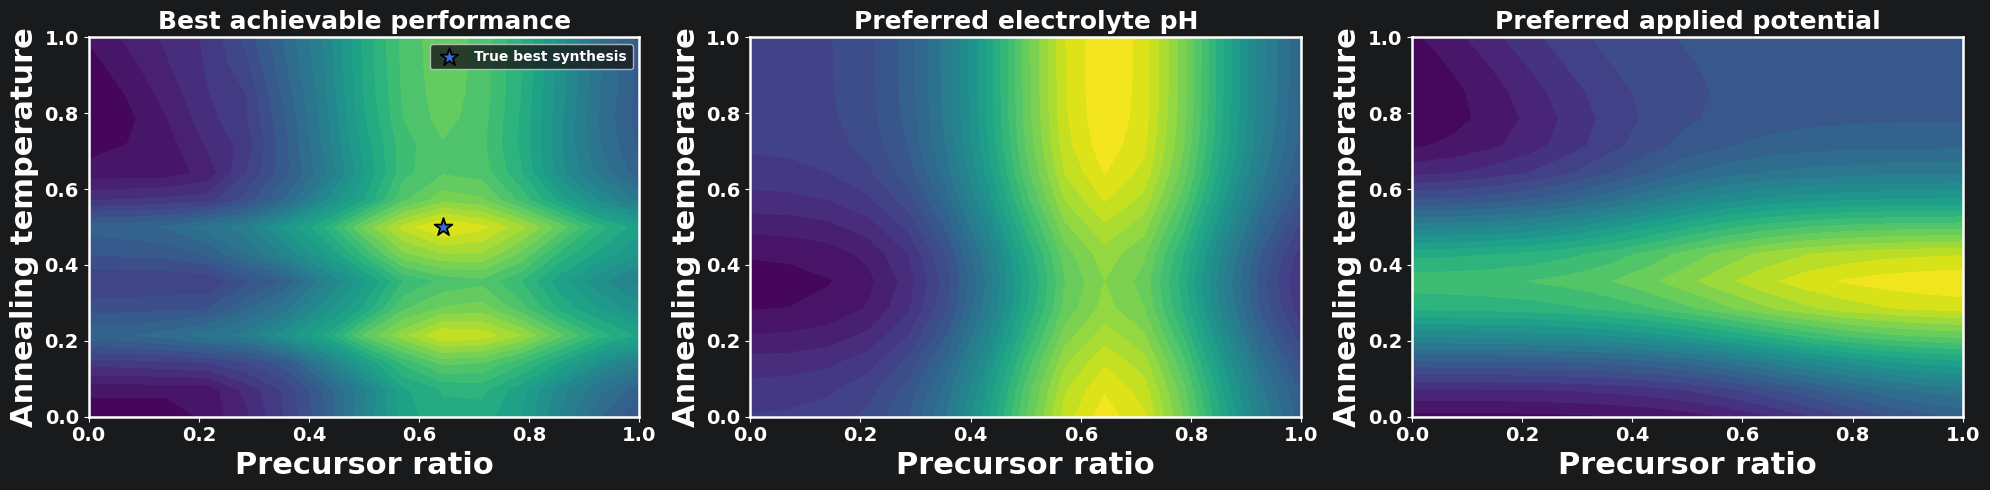

In [6]:
U1, U2 = synthesis_mesh
V1, V2 = operation_mesh

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

ax = axes[0]

c0 = ax.contourf(
    U1.numpy(),
    U2.numpy(),
    true_synthesis_grid.detach().cpu().numpy(),
    levels=30,
)

ax.scatter(
    float(true_best_U[0]),
    float(true_best_U[1]),
    s=180,
    marker="*",
    edgecolor="black",
    lw=1.3,
    label="True best synthesis",
)

ax.set_title("Best achievable performance", fontsize=18, fontweight="bold")
ax.set_xlabel("Precursor ratio", fontsize=22, fontweight="bold")
ax.set_ylabel("Annealing temperature", fontsize=22, fontweight="bold")
ax.legend(prop={"size": 10, "weight": "bold"})
style_ax(ax)


V_star = preferred_operation_from_synthesis(synthesis_pool)

ax = axes[1]

c1 = ax.contourf(
    U1.numpy(),
    U2.numpy(),
    V_star[:, 0].view(n_synthesis_axis, n_synthesis_axis).detach().cpu().numpy(),
    levels=30,
)

ax.set_title("Preferred electrolyte pH", fontsize=18, fontweight="bold")
ax.set_xlabel("Precursor ratio", fontsize=22, fontweight="bold")
ax.set_ylabel("Annealing temperature", fontsize=22, fontweight="bold")
style_ax(ax)


ax = axes[2]

c2 = ax.contourf(
    U1.numpy(),
    U2.numpy(),
    V_star[:, 1].view(n_synthesis_axis, n_synthesis_axis).detach().cpu().numpy(),
    levels=30,
)

ax.set_title("Preferred applied potential", fontsize=18, fontweight="bold")
ax.set_xlabel("Precursor ratio", fontsize=22, fontweight="bold")
ax.set_ylabel("Annealing temperature", fontsize=22, fontweight="bold")
style_ax(ax)

plt.tight_layout()
plt.show()

## 6. Inspect operation landscapes for selected synthesis conditions

This cell fixes three representative synthesis conditions and visualises the operation landscape for each one.

In the previous figure, we looked across the synthesis space and asked which operation condition each synthesis design prefers. Here, we reverse the view: we choose a few fixed synthesis conditions $U$ and then plot the objective over the operation variables $V$.

For each fixed synthesis condition, the plot shows:

1. the objective value $y(U,V)$ over electrolyte pH and applied potential;
2. the best operation condition available on the finite operation grid;
3. how the shape and location of the operation optimum changes when $U$ changes.

---

### Why this plot is useful

The operation response is not independent of synthesis. The preferred operation condition is defined as:

$$
V^*(U) = (v_1^*(U), v_2^*(U)).
$$

So when we change the synthesis condition $U$, we also change the material properties, and therefore change the operation landscape over $V$.

This is why the three panels do not have the same optimum location. Each panel corresponds to a different material produced by a different synthesis condition.

The star in each panel marks the best operation condition for that fixed synthesis condition.

---

### What to look for

The three synthesis examples are chosen to cover different regions of synthesis space:

- low precursor ratio and low annealing temperature;
- intermediate precursor ratio and annealing temperature;
- high precursor ratio and high annealing temperature.

The important feature is not the exact numerical choice of these examples. The important feature is that the peak in operation space moves across the panels.

That movement visually demonstrates the hierarchical structure:

$$
U \longrightarrow \text{material properties} \longrightarrow V^*(U).
$$

---

### Key takeaway

A synthesis condition does not merely have a single performance value by itself. Its measured performance depends on how it is operated.

So the optimisation problem is not just:

$$
\text{find a good synthesis condition},
$$

or:

$$
\text{find a good operation condition}.
$$

It is the coupled problem:

$$
\text{find a good synthesis condition and the operation condition that matches it}.
$$

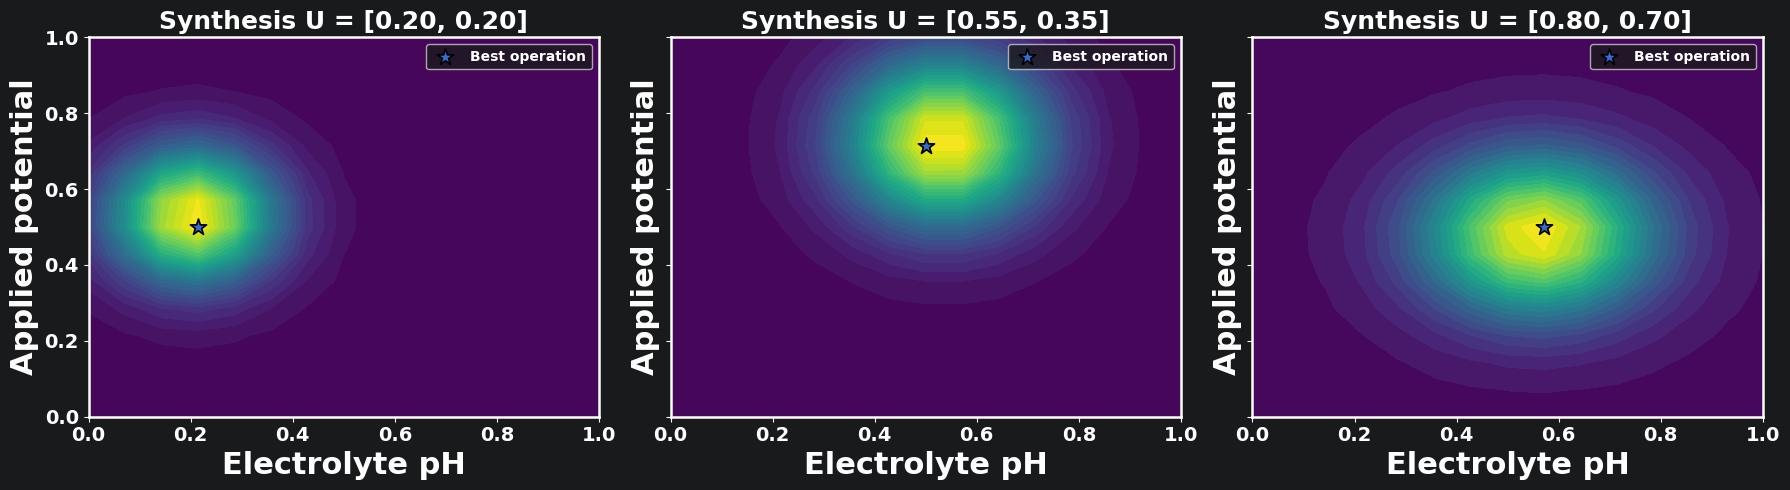

In [7]:
synthesis_examples = torch.tensor(
    [
        [0.20, 0.20],
        [0.55, 0.35],
        [0.80, 0.70],
    ],
    dtype=torch.double,
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

for ax, U_fixed in zip(axes, synthesis_examples):
    U_rep = U_fixed.unsqueeze(0).expand(operation_pool.shape[0], -1)
    Y_operation = hierarchical_objective(U_rep, operation_pool).view(
        n_operation_axis,
        n_operation_axis,
    )

    best_idx = torch.argmax(Y_operation.reshape(-1))
    best_V = operation_pool[best_idx]

    c = ax.contourf(
        V1.numpy(),
        V2.numpy(),
        Y_operation.detach().cpu().numpy(),
        levels=30,
    )

    ax.scatter(
        float(best_V[0]),
        float(best_V[1]),
        s=150,
        marker="*",
        edgecolor="black",
        lw=1.2,
        label="Best operation",
    )

    ax.set_title(
        f"Synthesis U = [{U_fixed[0]:.2f}, {U_fixed[1]:.2f}]",
        fontsize=18,
        fontweight="bold",
    )
    ax.set_xlabel("Electrolyte pH", fontsize=22, fontweight="bold")
    ax.set_ylabel("Applied potential", fontsize=22, fontweight="bold")
    ax.legend(prop={"size": 10, "weight": "bold"})
    style_ax(ax)

plt.tight_layout()
plt.show()

## 7. Choose the initial observations

This cell creates the **initial experimental dataset** that all optimisation policies will start from.

Before BO can fit a GP surrogate model, it needs a small number of observed synthesis-operation experiments.

Here, we randomly select `n_initial_pairs = 10` rows from the finite candidate library `variable_pool`.

Each selected row is one complete experiment:

$$
Z = [U,V] = [u_1,u_2,v_1,v_2].
$$

The first two entries are synthesis conditions, and the last two entries are operation conditions.

After selecting these candidate rows, the code looks up their corresponding objective values from `true_objective_values`.

Because this is a synthetic tutorial, the objective values are already known in the hidden ground-truth table.

In a real experiment, this step would correspond to actually running the selected synthesis-operation tests and recording their measured performance.

---

### Why the initial observations matter

The initial observations define what the optimiser knows before sequential decision-making begins.

This is why the initial design should be shared across methods. In this notebook, the same `initial_pair_indices` are passed to flat BO, two-stage structured BO, and random search.

That makes the comparison fair:

> all policies start from the same information, and only differ in how they choose the next experiment.

The line `set_seed(seed + 10)` also makes the random initial design reproducible, so rerunning the notebook gives the same starting dataset.

---

### What the table shows

The displayed dataframe records the initial experiments selected from the finite library.

It includes:

- `u1` and `u2`, the synthesis conditions;
- `v1` and `v2`, the operation conditions;
- `y`, the observed objective value for that complete experiment.

---

### Key takeaway

This cell defines the common starting point for the policy comparison.

Flat BO, two-stage structured BO, and random search all begin with the same 10 observed experiments.

After this point, their trajectories diverge because they use different rules for selecting the next synthesis-operation pair.

In [8]:
set_seed(seed + 10)

n_initial_pairs = 10

initial_pair_indices = torch.randperm(variable_pool.shape[0])[:n_initial_pairs]

initial_Z = variable_pool[initial_pair_indices]
initial_Y = true_objective_values[initial_pair_indices]

initial_df = pd.DataFrame({
    "u1": initial_Z[:, 0].detach().cpu().numpy(),
    "u2": initial_Z[:, 1].detach().cpu().numpy(),
    "v1": initial_Z[:, 2].detach().cpu().numpy(),
    "v2": initial_Z[:, 3].detach().cpu().numpy(),
    "y": initial_Y.view(-1).detach().cpu().numpy(),
})

display(initial_df)

print("Initial observations:", n_initial_pairs)

,u1,u2,v1,v2,y
0,0.071429,0.071429,0.642857,0.071429,0.489516
1,0.142857,0.285714,0.857143,1.000000,0.763120
2,0.928571,0.071429,0.071429,0.071429,0.912750
3,0.642857,0.428571,0.857143,0.285714,1.575640
4,0.857143,0.857143,0.571429,0.857143,1.099399
5,0.857143,0.142857,0.571429,0.857143,1.280661
6,0.357143,0.071429,0.214286,0.571429,0.858690
7,0.500000,0.285714,0.428571,0.928571,1.449847
8,0.857143,0.214286,0.428571,0.571429,2.158998
9,0.428571,0.642857,0.785714,1.000000,0.966577


Initial observations: 10


## 8. Define the selection rules for each policy

This cell defines the core bookkeeping and selection logic used by the optimisation loop.

It contains four helper functions:

- `make_history_entry`, which records the current best result and progress diagnostics.
- `select_flat_logei_pair`, which implements the flat BO selection rule.
- `select_two_stage_logei_pair`, which implements the structured two-stage BO selection rule.
- `select_random_pair`, which implements the random-search baseline.

The most important comparison is between `select_flat_logei_pair` and `select_two_stage_logei_pair`.

Both use the same GP model.

Both use the same acquisition function, `LogExpectedImprovement`.

Both choose from the same finite library `variable_pool`.

The difference is **how they use the acquisition values to choose the next experiment**.

---

### Bookkeeping: `make_history_entry`

The function `make_history_entry` records the current state of an optimisation run.

It looks at all experiments selected so far using `pair_indices`, and retrieves their objective values from `true_objective_values`.

It then finds the best observed candidate so far.

This is why the history dataframe can later plot `best_observed_y` against the number of observations.

The function also computes `n_unique_syntheses`, which the number of distinct synthesis conditions that have been explored so far.

---

### Flat BO selection rule

The function `select_flat_logei_pair` treats every complete synthesis-operation pair as an independent candidate.

Each candidate is a full vector:

$$
Z = [U,V] = [u_1,u_2,v_1,v_2].
$$

So flat BO asks:

$$
\arg\max_{U,V} \operatorname{LogEI}(U,V),
$$

as previously we have done.

In words, flat BO asks:

> Which single complete synthesis-operation experiment looks most promising right now?

This is a direct and aggressive rule.

It does not explicitly care whether two candidates share the same synthesis condition, it only ranks full four-dimensional candidates.

---

### Two-stage structured BO selection rule

The function `select_two_stage_logei_pair` uses the same LogEI values, but organises them differently.

Instead of only ranking full candidates, it reshapes the acquisition values into a matrix:

$$
\text{LogEI matrix shape}
=
(n_{\text{synthesis}}, n_{\text{operation}}).
$$

Rows correspond to synthesis conditions, and columns correspond to operation conditions.

So each row contains all operation candidates available under one synthesis condition.

This lets the method ask a synthesis-level question first:

> Which synthesis condition looks worth making, considering its most promising operation conditions?

After choosing the synthesis condition, the method chooses the best operation condition within that selected row.

So structured BO follows two stages:

1. score each synthesis condition using its best operation candidates;
2. choose the best operation condition under the selected synthesis condition.

This is different from flat BO because the synthesis condition is selected using grouped evidence across operation candidates.

---

### How `top_k_operation=5` works

The parameter `top_k_operation` controls how each synthesis condition is scored.

For each synthesis condition, the code looks at all unevaluated operation candidates under it.

It then takes the top `k` LogEI values from that row.

With `top_k_operation=5`, it takes the five most promising operation candidates for each synthesis condition and then averages those five LogEI values.

That average becomes the synthesis-level score.

Mathematically, for synthesis condition $U_i$:

$$
\text{synthesis score}(U_i)
=
\frac{1}{5}
\sum_{V \in \mathcal{T}_5(U_i)}
\operatorname{LogEI}(U_i,V),
$$

where $\mathcal{T}_5(U_i)$ is the set of the five highest-LogEI operation candidates under $U_i$.

This means the method does not commit to a synthesis condition just because of one promising operation candidate. It asks whether that synthesis condition has several promising operation candidates.

`top_k_operation=5` makes the synthesis-stage decision more robust than using only the single best operation candidate. If `top_k_operation=1`, the method becomes more aggressive. It scores each synthesis condition by its single best operation candidate.

If `top_k_operation` is larger, the method becomes more conservative. It favours synthesis conditions with broader operation promise rather than one sharp acquisition spike.

---

### Key difference between the two BO policies

Flat BO selects the best full pair directly:

$$
(U,V)_{\text{next}}
=
\arg\max_{U,V}
\operatorname{LogEI}(U,V).
$$

Structured BO first scores synthesis conditions, then chooses operation conditions:

$$
U_{\text{next}}
=
\arg\max_U
\operatorname{mean}
\left(
\text{top-k LogEI values under } U
\right).
$$

Then it selects:

$$
V_{\text{next}}
=
\arg\max_V
\operatorname{LogEI}(U_{\text{next}},V).
$$

So the two methods use the same surrogate and the same acquisition function.

The difference is the decision rule. Flat BO is full-pair centric. Structured BO is synthesis-first and operation-aware.

---

### Key takeaway

This cell defines the actual policy difference tested in the notebook.

The objective, model, candidate library, and acquisition function are shared.

The main experimental question is whether a synthesis-aware selection rule can make better use of the hierarchical workflow structure than a flat full-pair selection rule.

In [9]:
def make_history_entry(method, step, pair_indices):
    Y_seen = true_objective_values[pair_indices]
    Z_seen = variable_pool[pair_indices]

    best_local_idx = torch.argmax(Y_seen.view(-1))

    best_Z = Z_seen[best_local_idx]
    best_Y = Y_seen[best_local_idx]

    synthesis_indices = pair_indices // n_operation_pool

    return {
        "method": method,
        "step": step,
        "n_observations": int(pair_indices.numel()),
        "n_unique_syntheses": int(torch.unique(synthesis_indices).numel()),
        "best_u1": float(best_Z[0]),
        "best_u2": float(best_Z[1]),
        "best_v1": float(best_Z[2]),
        "best_v2": float(best_Z[3]),
        "best_observed_y": float(best_Y),
    }

def select_flat_logei_pair(model, evaluated_mask, train_Y):
    best_f = train_Y.max()

    available_mask = ~evaluated_mask
    available_indices = torch.where(available_mask)[0]
    available_Z = variable_pool[available_indices]

    acq = LogExpectedImprovement(model=model, best_f=float(best_f))

    with torch.no_grad():
        logei_values = acq(available_Z.unsqueeze(1)).view(-1)

    best_local_idx = torch.argmax(logei_values)
    selected_pair_idx = available_indices[best_local_idx]

    return selected_pair_idx, {
        "logei": float(logei_values[best_local_idx]),
        "n_available": int(available_indices.numel()),
    }

def select_two_stage_logei_pair(model, evaluated_mask, train_Y, top_k_operation=5):
    best_f = train_Y.max()

    acq = LogExpectedImprovement(model=model, best_f=float(best_f))

    with torch.no_grad():
        logei_values = acq(variable_pool.unsqueeze(1)).view(-1)

    logei_matrix = logei_values.view(n_synthesis_pool, n_operation_pool)
    evaluated_matrix = evaluated_mask.view(n_synthesis_pool, n_operation_pool)

    logei_matrix_masked = logei_matrix.clone()
    logei_matrix_masked[evaluated_matrix] = -float("inf")

    synthesis_scores = torch.full((n_synthesis_pool,), -float("inf"), dtype=torch.double)

    for synthesis_idx in range(n_synthesis_pool):
        available_values = logei_matrix_masked[synthesis_idx]
        finite_values = available_values[torch.isfinite(available_values)]

        if finite_values.numel() == 0:
            continue

        k = min(top_k_operation, finite_values.numel())
        synthesis_scores[synthesis_idx] = torch.topk(finite_values, k=k).values.mean()

    selected_synthesis_idx = torch.argmax(synthesis_scores)
    selected_operation_idx = torch.argmax(logei_matrix_masked[selected_synthesis_idx])
    selected_pair_idx = selected_synthesis_idx * n_operation_pool + selected_operation_idx

    return selected_pair_idx, {
        "synthesis_score": float(synthesis_scores[selected_synthesis_idx]),
        "top_k_operation": int(top_k_operation),
    }

def select_random_pair(evaluated_mask):
    available_indices = torch.where(~evaluated_mask)[0]
    random_local_idx = torch.randint(0, available_indices.numel(), size=(1,))
    selected_pair_idx = available_indices[random_local_idx].squeeze(0)

    return selected_pair_idx

## 9. Define the sequential optimisation loop

This cell defines the main optimisation loop used by all three policies.

The function `run_pair_library_policy` starts from the shared initial observations, repeatedly fits a GP model when needed, selects one new synthesis-operation pair, updates the evaluated set, and records the optimisation history.

The same loop is used for flat BO, two-stage structured BO, and random search. The only difference is which selection function is called inside the loop.

---

### What the loop keeps track of

The optimisation state is represented by two objects:

- `evaluated_mask`, which marks which rows of `variable_pool` have already been tested;
- `pair_indices`, which stores the sequence of selected candidate rows.

At the start, both are initialised from `initial_pair_indices`.

Then, after every new selection, the new candidate index is appended to `pair_indices`, and the corresponding entry in `evaluated_mask` is set to `True`.

This prevents the same synthesis-operation pair from being selected twice.

---

### GP fitting inside the loop

For the BO-based methods, the loop fits a `SingleTaskGP` at every step using the observations collected so far.

The training inputs are:

$$
Z = [U,V],
$$

stored as `train_Z`.

The training outputs are the observed objective values stored as `train_Y`.

The GP uses `Normalize` on the inputs and `Standardize` on the outputs. This keeps the model numerically stable and makes the surrogate easier to fit.

Random search does not need a GP model, so the fitting block is skipped for that method.

---

### How the method choice works

The argument `method` determines which policy is used to select the next experiment.

If `method == "Flat BO"`, the loop calls `select_flat_logei_pair`.

This chooses the full synthesis-operation pair with the highest LogEI value.

If `method == "Two-stage structured BO"`, the loop calls `select_two_stage_logei_pair`.

This first scores synthesis conditions using the top operation candidates under each synthesis condition, then chooses the best operation condition under the selected synthesis condition.

If `method == "Random search"`, the loop calls `select_random_pair`.

This samples one unevaluated candidate from the library without using the GP or acquisition function.

---

### What the function returns

The function returns the full selected sequence and a history list.

The selected sequence is stored in `pair_indices`.

The history list stores one entry per step, including the best observed value so far and the number of unique synthesis conditions explored.

These records are later converted into dataframes and used to compare the three policies visually.

---

### Key takeaway

This cell defines the shared sequential optimisation loop.

Flat BO, structured BO, and random search all use the same initial observations, candidate library, objective values, and history format.

The comparison is therefore controlled: the only major difference between the methods is the rule used to select the next synthesis-operation pair.

In [10]:
def run_pair_library_policy(
    method,
    n_steps,
    initial_pair_indices,
    seed_run=0,
    top_k_operation=5,
):
    set_seed(seed_run)

    evaluated_mask = torch.zeros(variable_pool.shape[0], dtype=torch.bool)
    evaluated_mask[initial_pair_indices] = True

    pair_indices = initial_pair_indices.clone()

    history = []
    history.append(make_history_entry(method, step=0, pair_indices=pair_indices))

    for step in range(1, n_steps + 1):
        train_Z = variable_pool[pair_indices]
        train_Y = true_objective_values[pair_indices]

        if method in ["Flat BO", "Two-stage structured BO"]:
            model = SingleTaskGP(
                train_X=train_Z,
                train_Y=train_Y,
                input_transform=Normalize(d=train_Z.shape[-1]),
                outcome_transform=Standardize(m=1),
            )

            mll = ExactMarginalLogLikelihood(model.likelihood, model)
            fit_gpytorch_mll(mll)
            model.eval()

        if method == "Flat BO":
            selected_pair_idx, info = select_flat_logei_pair(
                model=model,
                evaluated_mask=evaluated_mask,
                train_Y=train_Y,
            )

        elif method == "Two-stage structured BO":
            selected_pair_idx, info = select_two_stage_logei_pair(
                model=model,
                evaluated_mask=evaluated_mask,
                train_Y=train_Y,
               top_k_operation=top_k_operation,
            )

        elif method == "Random search":
            selected_pair_idx = select_random_pair(evaluated_mask)

        else:
            raise ValueError(f"Unknown method: {method}")

        pair_indices = torch.cat([pair_indices, selected_pair_idx.view(1)])
        evaluated_mask[selected_pair_idx] = True

        history.append(make_history_entry(method, step=step, pair_indices=pair_indices))

    return {
        "method": method,
        "pair_indices": pair_indices,
        "history": history,
    }

## 10. Run the three optimisation policies

This cell actually runs the three policies defined above.

Each policy starts from the same initial observations and is allowed to select `n_bo_steps = 50` additional synthesis-operation experiments.

The three policies are:

- flat BO;
- two-stage structured BO;
- random search.

The seed `bo_comparison_seed` is kept the same across the three runs.

This keeps the comparison more controlled, especially for the BO-based methods, because unnecessary differences from random initialisation are reduced.

---

### What is being compared

Flat BO and two-stage structured BO use the same GP model, the same observed data, the same candidate library, and the same LogEI acquisition function.

The difference is their selection rule:

- Flat BO directly selects the full synthesis-operation pair with the highest acquisition value.
- Structured BO first scores synthesis conditions using their best operation candidates, then selects an operation condition under the chosen synthesis condition.

Random search is included as a baseline. It does not fit a GP model and does not use acquisition values. It simply selects unevaluated candidate experiments at random.

---

### Why we convert results into history dataframes

Each call to `run_pair_library_policy` returns a dictionary containing the selected pair indices and the recorded optimisation history.

The history is converted into a dataframe so that we can plot and compare the trajectories.

The important columns are:

- `n_observations`, the number of experiments observed so far;
- `best_observed_y`, the best objective value found so far;
- `n_unique_syntheses`, the number of distinct synthesis conditions explored.

These diagnostics let us compare not only which method finds the best candidate, but also how each method explores the synthesis space.

---

### Key takeaway

This cell runs the actual policy comparison.

After this point, `flat_bo_hist`, `structured_hist`, and `random_hist` contain the optimisation trajectories that will be visualised in the next cell.

In [11]:
n_bo_steps = 50
bo_comparison_seed = seed + 500

flat_bo_result = run_pair_library_policy(
    method="Flat BO",
    n_steps=n_bo_steps,
    initial_pair_indices=initial_pair_indices,
    seed_run=bo_comparison_seed,
)

structured_result = run_pair_library_policy(
    method="Two-stage structured BO",
    n_steps=n_bo_steps,
    initial_pair_indices=initial_pair_indices,
    seed_run=bo_comparison_seed,
    top_k_operation=5,
)

random_result = run_pair_library_policy(
    method="Random search",
    n_steps=n_bo_steps,
    initial_pair_indices=initial_pair_indices,
    seed_run=bo_comparison_seed,
)

flat_bo_hist = pd.DataFrame(flat_bo_result["history"])
structured_hist = pd.DataFrame(structured_result["history"])
random_hist = pd.DataFrame(random_result["history"])

## 11. Compare optimisation trajectories

This cell compares the optimisation trajectories from flat BO, two-stage structured BO, and random search.

The figure has two panels.

The left panel tracks how quickly each method discovers high-performing synthesis-operation pairs, while the right panel tracks how many distinct synthesis conditions each method explores.

Together, they compare both **performance discovery** and **search behaviour**.

---

### Best discovered performance

The left panel plots `best_observed_y` against `n_observations`.

This is a cumulative-best curve:

$$
\text{best observed value at step } t
=
\max_{i \leq t} y_i.
$$

The curve only increases when a newly selected experiment improves on all previous observations.

A flat region therefore does not mean the method is inactive; it means the newly selected experiments have not yet beaten the current best value.

The dashed horizontal line marks the true best value in the finite candidate library.

Since this is a synthetic tutorial, we can compute that value in advance and use it as a reference when judging whether a policy has actually found the best available synthesis-operation pair.

In this run:
- Two-stage structured BO is the only method that reaches the true finite-library optimum.
- Flat BO improves faster at the beginning and finds a strong candidate early, but it plateaus below the optimum.
- Random search improves much less and stalls well below both BO-based methods.

So the main performance conclusion is not just that structured BO works, but that it eventually converts the synthesis-operation hierarchy into a better final recommendation than flat BO in this example.

---

### Unique synthesis designs explored

The right panel plots `n_unique_syntheses`. This counts how many distinct synthesis conditions have been tested so far.

It is included because the structured policy is designed to reason at the synthesis-condition level, not only at the full synthesis-operation pair level.

Random search explores the largest number of synthesis conditions, which is expected because it samples broadly from the full library without any model-based filtering.

Flat BO and structured BO are more selective, so they revisit synthesis regions that appear promising.

Structured BO explores slightly fewer synthesis conditions than flat BO for most of the run, but still finds the best overall candidate.

That is an important point: **broader synthesis exploration is not automatically better**. In this example, structured BO achieves the best final performance without needing to explore the synthesis space most aggressively.

---

### How to read the figure

The two panels should be interpreted together.
- The left panel asks which method finds high objective values fastest.
- The right panel asks how broadly each method explores the synthesis space.

Taken together, the figure suggests a clear trade-off.

Random search explores broadly but inefficiently.

Flat BO is more sample-efficient than random search and improves quickly, but it treats each full synthesis-operation pair independently and does not fully exploit the synthesis-level structure.

Structured BO improves more gradually at first, but its synthesis-aware selection rule eventually helps it identify the best finite-library candidate.

---

### Key takeaway

This figure compares both the outcome and the search behaviour of the three policies.

In this run, preserving the synthesis-operation structure changes the search trajectory in a useful way: two-stage structured BO ultimately reaches the true finite-library optimum, whereas flat BO and random search do not.

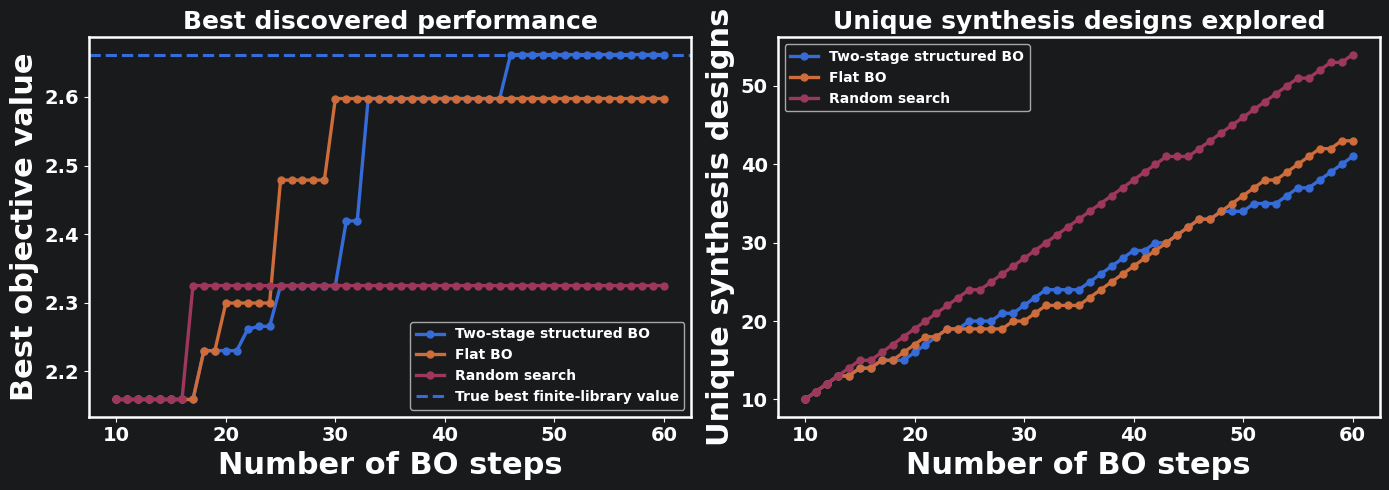

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]

for hist, label in [
    (structured_hist, "Two-stage structured BO"),
    (flat_bo_hist, "Flat BO"),
    (random_hist, "Random search"),
]:
    ax.plot(
        hist["n_observations"],
        hist["best_observed_y"],
        "-o",
        lw=2.4,
        markersize=5,
        label=label,
    )

ax.axhline(
    float(true_best_value),
    linestyle="--",
    lw=2.2,
    label="True best finite-library value",
)

ax.set_title("Best discovered performance", fontsize=18, fontweight="bold")
ax.set_xlabel("Number of BO steps", fontsize=22, fontweight="bold")
ax.set_ylabel("Best objective value", fontsize=22, fontweight="bold")
ax.legend(prop={"size": 10, "weight": "bold"})
style_ax(ax)


ax = axes[1]

for hist, label in [
    (structured_hist, "Two-stage structured BO"),
    (flat_bo_hist, "Flat BO"),
    (random_hist, "Random search"),
]:
    ax.plot(
        hist["n_observations"],
        hist["n_unique_syntheses"],
        "-o",
        lw=2.4,
        markersize=5,
        label=label,
    )

ax.set_title("Unique synthesis designs explored", fontsize=18, fontweight="bold")
ax.set_xlabel("Number of BO steps", fontsize=22, fontweight="bold")
ax.set_ylabel("Unique synthesis designs", fontsize=22, fontweight="bold")
ax.legend(prop={"size": 10, "weight": "bold"})
style_ax(ax)

plt.tight_layout()
plt.show()

## 🧭 Closing Remarks

In this tutorial, we moved from standard flat BO to a more structured view of experimental design.

The central idea was that realistic optimisation workflows are not always well described by one undifferentiated input vector:

$$
Z = [z_1, z_2, z_3, z_4].
$$

Instead, many workflows have an internal hierarchy.

In this notebook, that hierarchy was:

- **synthesis conditions**, which determine what material is made;
- **operation conditions**, which determine how that material is tested.

So the BO problem was not only:

> **which full candidate should we evaluate next?**

It also invited a more workflow-aware question:

> **which synthesis condition is worth committing to, given the operation conditions that look promising under it?**

---

### Hierarchical objective

The synthetic objective was designed to reflect this structure.

A synthesis condition $U$ first determined latent material properties:

$$
U \longrightarrow P(U).
$$

Those material properties then determined a preferred operation condition:

$$
P(U) \longrightarrow V^*(U).
$$

Finally, the observed performance depended on both the intrinsic material quality and how well the chosen operation condition matched that preferred region:

$$
y(U,V).
$$

This mattered because it created a problem in which operation optimisation was genuinely conditional on synthesis.

There was no single globally best operation condition independent of the material. So the objective was not just a flat four-dimensional landscape. It was a hierarchical workflow written in BO form.

---

### Flat BO vs structured BO

Both flat BO and two-stage structured BO used the same ingredients:

- the same synthetic objective;
- the same finite candidate library;
- the same GP surrogate model;
- the same Log Expected Improvement acquisition function.

The key difference was the selection rule.

Flat BO treated each full synthesis-operation pair as an ordinary candidate and selected the pair with the highest acquisition value:

$$
\arg\max_{U,V} \operatorname{LogEI}(U,V).
$$

Structured BO used the same acquisition values, but reorganised them by synthesis condition.

For each synthesis condition, it looked across the available operation candidates and formed a synthesis-level score from the top `k` operation candidates.

This led to a two-stage decision:

1. choose a promising synthesis condition;
2. then choose the best operation condition under that synthesis condition.

So structured BO did not change the target function. It changed how the optimiser used the workflow structure when deciding what to test next.

---

### What the optimisation comparison showed

The final comparison gave a clear outcome in this run.

- Random search explored broadly, but it was the least efficient in terms of best value discovered.
- Flat BO improved quickly at the beginning and found strong candidates early. However, it eventually plateaued below the true best finite-library value.
- Two-stage structured BO improved more gradually at first, but eventually reached the true finite-library optimum.

That is the most important result of the tutorial.

The lesson is not that structured BO is always universally better than flat BO.

The more careful lesson is:

> when the workflow genuinely has a hierarchy, a synthesis-aware selection rule can convert that structure into a better search trajectory.

The right-hand diagnostic also showed that exploring more distinct synthesis conditions is not automatically better. Random search explored the most synthesis conditions, yet performed worst.

Structured BO explored fewer synthesis conditions than random search, and slightly fewer than flat BO for much of the run, but still found the best final candidate.

So the value of structured BO was not brute-force breadth. It was more targeted synthesis-level reasoning.

---

### Final takeaway

This notebook showed one important way in which BO becomes more realistic:

> the optimiser may need to respect the internal structure of the experimental workflow, rather than treating every variable as playing the same role.

In this example, synthesis conditions and operation conditions were both part of the input, but they were not interchangeable.

Synthesis determined the material. Operation determined how that material should be tested.

So the broader message of this tutorial is:

> **structured BO does not change what the objective is, but it can change how the optimiser makes decisions when the workflow has meaningful internal hierarchy.**

That is the main reason nested and structured BO matter in practice.

They allow the optimisation policy to reflect how real experiments are actually organised, rather than only how they can be concatenated into a flat vector.